# Glasbeyカラーパレットを使用する



In [25]:
import glasbey
import numpy as np
from skimage import data
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.morphology import closing, remove_small_objects
from skimage.segmentation import clear_border
import matplotlib.pyplot as plt
import seaborn as sns

import napari
from napari.utils import CyclicLabelColormap

## 元の画像

元の画像は[scikit-image](https://scikit-image.org/)のサンプルを使います。

<positron-console-cell-26>:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


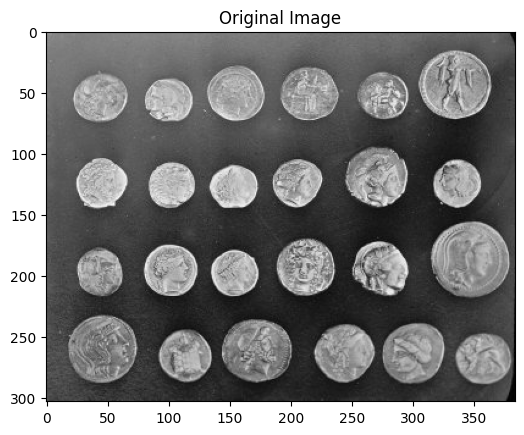

In [26]:
image = data.coins()
fig, ax = plt.subplots()
ax.imshow(image, cmap='gray')
ax.set_title('Original Image')
fig.show()

## 二値化処理

色分けラベルを作るため、画像の二値化処理を行います。

<positron-console-cell-27>:6: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
<positron-console-cell-27>:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


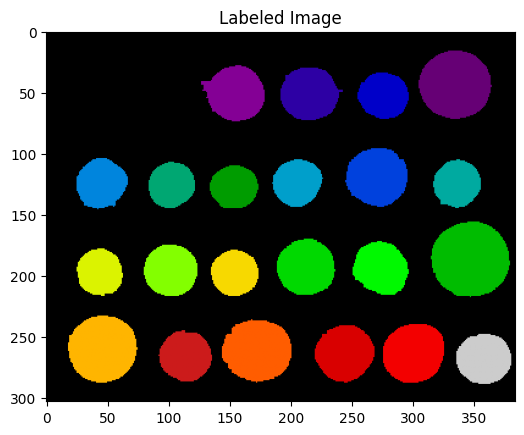

In [27]:
# apply threshold
thresh = threshold_otsu(image)
bw = closing(image > thresh, footprint=np.ones((4, 4), dtype=bool))

# remove artifacts connected to image border
cleared = remove_small_objects(clear_border(bw), 20)

# label image regions
label_image = label(cleared).astype("uint8")

fig, ax = plt.subplots()
ax.imshow(label_image, cmap='nipy_spectral')
ax.set_title('Labeled Image')
fig.show()

## Glasbeyカラーパレットの定義

`glasbey.create_palette()`を使用して、カラーパレットを作成します。
第一引数の`palette_size`に色数を指定します。
カラーパレットは、[seaborn](https://seaborn.pydata.org/index.html)の`palplot()`関数で可視化できます。

['#d70041', '#1869ff', '#008a00']


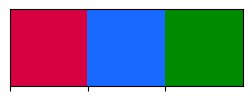

In [28]:
glasbey_palette = glasbey.create_palette(palette_size=3)
print(glasbey_palette)
sns.palplot(glasbey_palette)

## napariで使うカラーパレットの定義

napariで使うカラーパレットは**colormap**と呼ばれます。
どのIDにどの色を割り当てるかを表します。
colormapには、CyclicLabelColormapとDirectLabelColormapの二種類があります。
CyclicLabelColormapは、指定色数をIDの数が上回ると、色を繰り返し使用します。
DirectLabelColormapは、各IDに対して一意の色を割り当てます。

colormapの最初は、無色透明とデフォルトで決まっているようです。
このラベルは通常、背景色として使用されます。
自分でパレットを指定した場合、1番目が無色透明に上書きされるようなので、colormapの作成の際に、`transparent`を1番目に与えることで、自分で指定したカラーパレットの色がすべて使用されます。

In [36]:
cmap_glasbey = CyclicLabelColormap(
    colors=['transparent'] + glasbey_palette,
)
print(cmap_glasbey)

colors=ColorArray([[0.        , 0.        , 0.        , 0.        ],
            [0.84313726, 0.        , 0.25490198, 1.        ],
            [0.09411765, 0.4117647 , 1.        , 1.        ],
            [0.        , 0.5411765 , 0.        , 1.        ]],
           dtype=float32) name='custom' interpolation=<ColormapInterpolationMode.ZERO: 'zero'> controls=array([0.  , 0.25, 0.5 , 0.75, 1.  ], dtype=float32) nan_color=ColorValue([0., 0., 0., 0.], dtype=float32) high_color=None low_color=None use_selection=False selection=0 background_value=0 seed=0.5


## ラベルの確認

以下のコードでnapariを起動すると、コインが指定した色で塗り分けられていることが確認できます。

In [37]:
viewer, image_layer = napari.imshow(image, name='coins')

# add the labels
label_layer_glas = viewer.add_labels(
        label_image, name='segmentation', colormap=cmap_glasbey
        )

if __name__ == '__main__':
    napari.run()

## 参考

- [Glasbey Categorical Color Palette Tools — glasbey documentation](https://glasbey.readthedocs.io/en/stable/index.html)
- [Glasbey colormap — napari](https://napari.org/stable/gallery/glasbey-colormap.html)